# 01 — Baseline: Raw Model Performance

> **Research Question**
>
> **How capable is the base Qwen2.5-3B-Instruct model at routing tool calls without any task-specific optimization?**

---

## Purpose

A common mistake when evaluating language models is to immediately optimize prompts or fine-tune the model without first measuring its native capabilities.

This notebook deliberately avoids any task-specific optimization in order to establish a meaningful reference point.

Before introducing prompt engineering, dataset construction or supervised fine-tuning, it is essential to establish an objective baseline.

This notebook evaluates the routing capabilities of the base model under deterministic inference conditions. The results obtained here serve as the reference point for every subsequent experiment.

Specifically, this notebook answers the following questions:

- Can the model consistently generate valid routing outputs?
- Which tools are already routed reliably?
- Which routing ambiguities remain?
- Which limitations motivate prompt engineering?

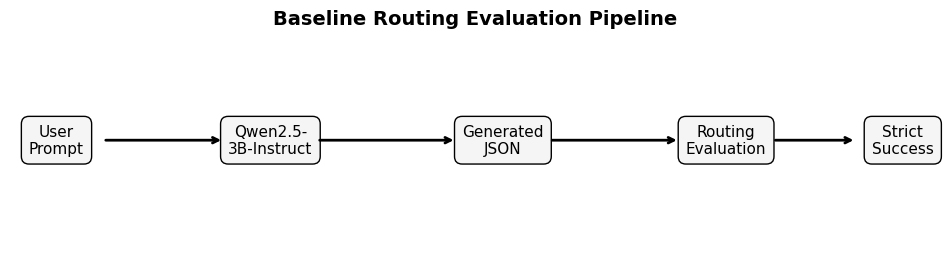

In [1]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 2.8))
ax.axis("off")

steps = [
    ("User\nPrompt", 0.05),
    ("Qwen2.5-\n3B-Instruct", 0.28),
    ("Generated\nJSON", 0.53),
    ("Routing\nEvaluation", 0.77),
    ("Strict\nSuccess", 0.96),
]

for label, x in steps:
    ax.text(
        x,
        0.5,
        label,
        ha="center",
        va="center",
        fontsize=11,
        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor="#F5F5F5",
            edgecolor="black",
        ),
    )

for i in range(len(steps) - 1):
    ax.annotate(
        "",
        xy=(steps[i + 1][1] - 0.05, 0.5),
        xytext=(steps[i][1] + 0.05, 0.5),
        arrowprops=dict(arrowstyle="->", lw=2),
    )

plt.title("Baseline Routing Evaluation Pipeline", fontsize=14, weight="bold")
plt.show()

## Notebook Roadmap

This notebook is organized as follows:

1. Experimental setup
2. Baseline evaluation
3. Error analysis
4. Discussion
5. Key takeaways

Every subsequent notebook builds upon the observations made in this baseline evaluation.

## Experimental Setup

This notebook evaluates the routing capabilities of the **base Qwen2.5-3B-Instruct model** without any task-specific optimization.

The model receives only the benchmark instructions and is expected to produce structured routing decisions for a local AI assistant exposing 37 different tools.

The objective is to establish a reliable baseline before introducing prompt engineering or supervised fine-tuning.

## Benchmark Overview

The routing benchmark covers a broad range of user requests representative of everyday interactions with the assistant.

The benchmark includes:

- 37 available tools
- 320 single-step prompts
- 50 multi-step scenarios
- manually validated expected outputs

This diversity ensures that the evaluation reflects realistic usage rather than isolated synthetic examples.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("default")

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.dpi": 150,
})

In [3]:

setup = pd.DataFrame(
    {
        "Parameter": [
            "Model",
            "Quantization",
            "Hardware",
            "Runtime",
            "System Prompt",
            "Temperature",
            "Top-p",
            "Available Tools",
            "Single-step Prompts",
            "Multi-step Scenarios",
        ],
        "Value": [
            "Qwen2.5-3B-Instruct",
            "Q6_K (GGUF)",
            "Apple M4, 16GB unified RAM",
            "llama-server (llama.cpp)",
            'You are a macOS assistant. If a tool is needed, respond with JSON: {"tool": "TOOL_NAME", "params": {}} Otherwise respond normally.',
            0.0,
            1.0,
            37,
            320,
            50,
        ],
    }
)

setup

,Parameter,Value
0,Model,Qwen2.5-3B-Instruct
1,Quantization,Q6_K (GGUF)
2,Hardware,"Apple M4, 16GB unified RAM"
3,Runtime,llama-server (llama.cpp)
4,System Prompt,You are a macOS assistant. If a tool is needed...
5,Temperature,0.0
6,Top-p,1.0
7,Available Tools,37
8,Single-step Prompts,320
9,Multi-step Scenarios,50


## Evaluation Metrics

The benchmark reports several complementary metrics.

- **Valid JSON** measures whether the generated response follows the required JSON schema.
- **Category Accuracy** evaluates whether the predicted routing category is correct.
- **Tool Accuracy** measures whether the correct tool has been selected.
- **Parameter Accuracy** evaluates the extraction of tool arguments.
- **Strict Pass Rate** requires every routing component to be correct simultaneously.
- **Application Success** estimates whether the assistant would successfully execute the user's request.

## Benchmark Protocol

Each prompt is evaluated independently against a manually validated reference.

A prediction is considered strictly correct only if all of the following components match the expected output:

- valid JSON structure,
- routing category,
- tool name,
- extracted parameters.

This strict evaluation protocol prevents partially correct predictions from artificially inflating the reported performance.

## Single-Step Evaluation

The first experiment evaluates isolated user requests independently.

Each prompt requires selecting the appropriate routing category, tool, and parameters while respecting the expected JSON format.

In [4]:
results = {
    "valid_json": 15,
    "category": 0,
    "tool": 0,
    "params": 4,
    "strict": 0,
    "success": 0,
    "latency": 2.08,
}

single_step = pd.DataFrame(
    {
        "Metric": [
            "Valid JSON",
            "Category Accuracy",
            "Tool Accuracy",
            "Parameter Accuracy",
            "Strict Pass Rate",
            "Application Success",
            "Average Latency",
        ],
        "Value": [
            results["valid_json"],
            results["category"],
            results["tool"],
            results["params"],
            results["strict"],
            results["success"],
            results["latency"],
        ],
    }
)

single_step = single_step.set_index("Metric")

display(single_step)

,Value
Metric,
Valid JSON,15.00
Category Accuracy,0.00
Tool Accuracy,0.00
Parameter Accuracy,4.00
Strict Pass Rate,0.00
Application Success,0.00
Average Latency,2.08


### Figure 1 - Single-Step Routing Performance

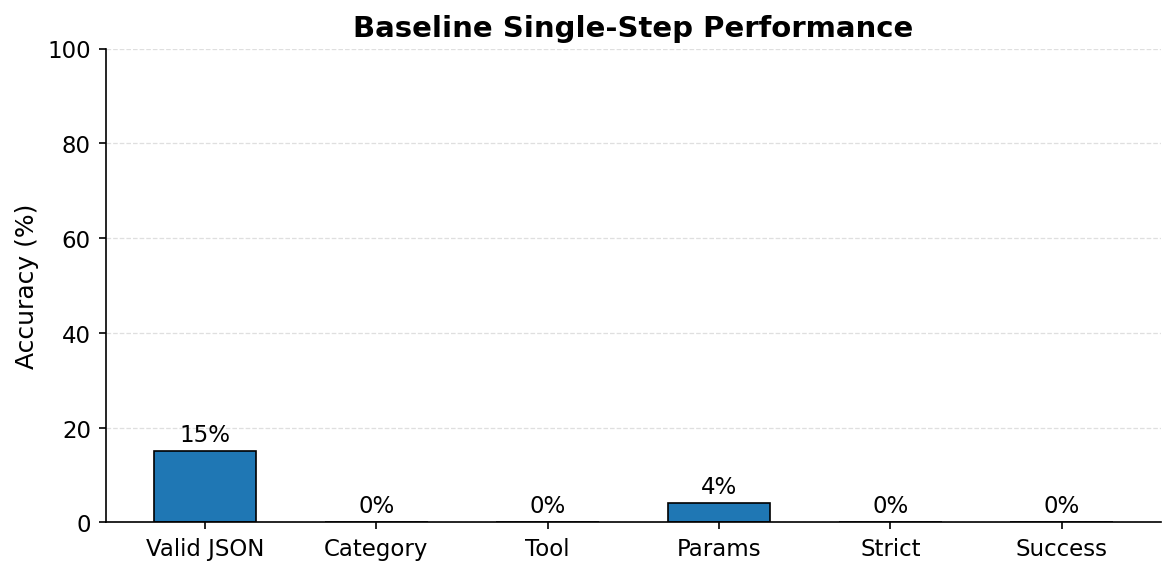

In [5]:
plot = pd.DataFrame(
    {
        "Metric": [
            "Valid JSON",
            "Category",
            "Tool",
            "Params",
            "Strict",
            "Success",
        ],
        "Accuracy": [15, 0, 0, 4, 0, 0],
    }
)

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(
    plot["Metric"],
    plot["Accuracy"],
    width=0.6,
    edgecolor="black",
    linewidth=0.8,
)

for bar in bars:
    value = bar.get_height()

    ax.annotate(
        f"{value:.0f}%",
        (
            bar.get_x() + bar.get_width() / 2,
            value
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        fontsize=11
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4
)

ax.set_ylabel("Accuracy (%)")
ax.set_title("Baseline Single-Step Performance")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

### Discussion

The base model performs extremely poorly on the routing task.

Although valid JSON is occasionally produced, the model is unable to correctly identify routing categories or tool names.

The near-zero strict pass rate indicates that the model lacks an understanding of the routing protocol required by the assistant.

These results demonstrate that general instruction tuning alone is insufficient for reliable tool routing.

The next section investigates whether these failures are uniformly distributed across all tools or concentrated on a small subset.

To better understand the origin of these failures, the next section investigates parameter extraction accuracy for individual tools.

## Tool-Level Analysis

The poor overall performance is reflected across nearly every available tool.

Most tools achieve **0% routing accuracy**, suggesting that the failure is systematic rather than limited to a few difficult cases.

### Figure 2 - Parameter Extraction

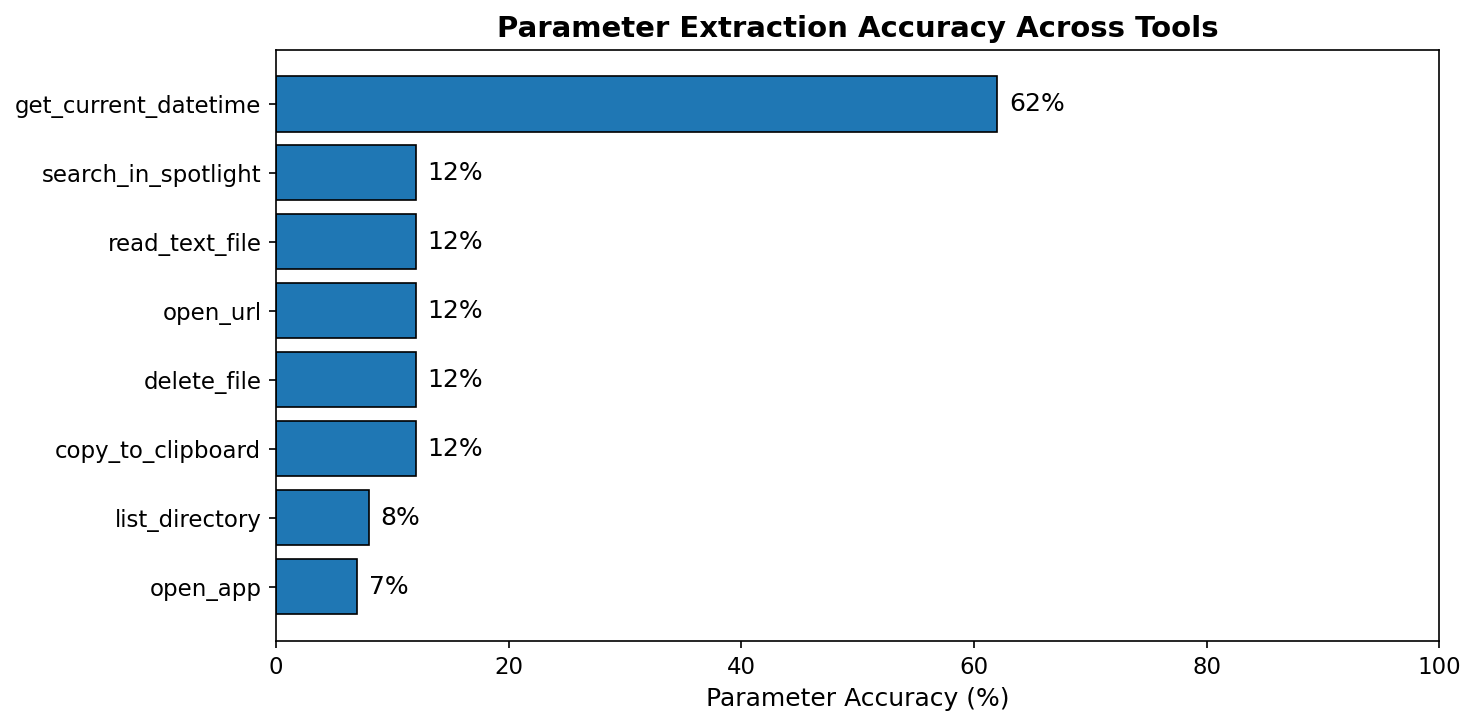

In [6]:
tool_params = pd.DataFrame({
    "Tool": [
        "get_current_datetime",
        "copy_to_clipboard",
        "delete_file",
        "open_url",
        "read_text_file",
        "search_in_spotlight",
        "list_directory",
        "open_app"
    ],
    "Accuracy": [
        62,
        12,
        12,
        12,
        12,
        12,
        8,
        7
    ]
})

tool_params = tool_params.sort_values(
    "Accuracy",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10,5))

bars = ax.barh(
    tool_params["Tool"],
    tool_params["Accuracy"],
    edgecolor="black",
    linewidth=0.8,
)

ax.set_xlim(0,100)

ax.set_xlabel("Parameter Accuracy (%)")

ax.set_title("Parameter Extraction Accuracy Across Tools")

for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 1,
        bar.get_y() + bar.get_height()/2,
        f"{width:.0f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

### Observation

Interestingly, a few tools achieve non-zero parameter extraction despite never selecting the correct routing category or tool.

This suggests that the language model is capable of extracting useful information from the prompt but lacks the routing policy required to associate that information with the correct tool.

## Multi-Step Evaluation

The second benchmark evaluates complete workflows requiring multiple sequential tool calls.

This experiment measures not only tool selection but also the ability to maintain context across several reasoning steps.

In [7]:
multi = pd.DataFrame(
{
"Metric":[
"Scenarios",
"Model Calls",
"Valid JSON",
"Step Accuracy",
"Tool Order",
"Final Accuracy",
"Loop Completion",
"Latency",
],
"Value":[
50,
112,
"76%",
"45%",
"42%",
"42%",
"42%",
"3.00 s",
]
}
)

multi = multi.set_index("Metric")

display(multi)

,Value
Metric,
Scenarios,50
Model Calls,112
Valid JSON,76%
Step Accuracy,45%
Tool Order,42%
Final Accuracy,42%
Loop Completion,42%
Latency,3.00 s


### Figure 3 - Multi-Step Performance

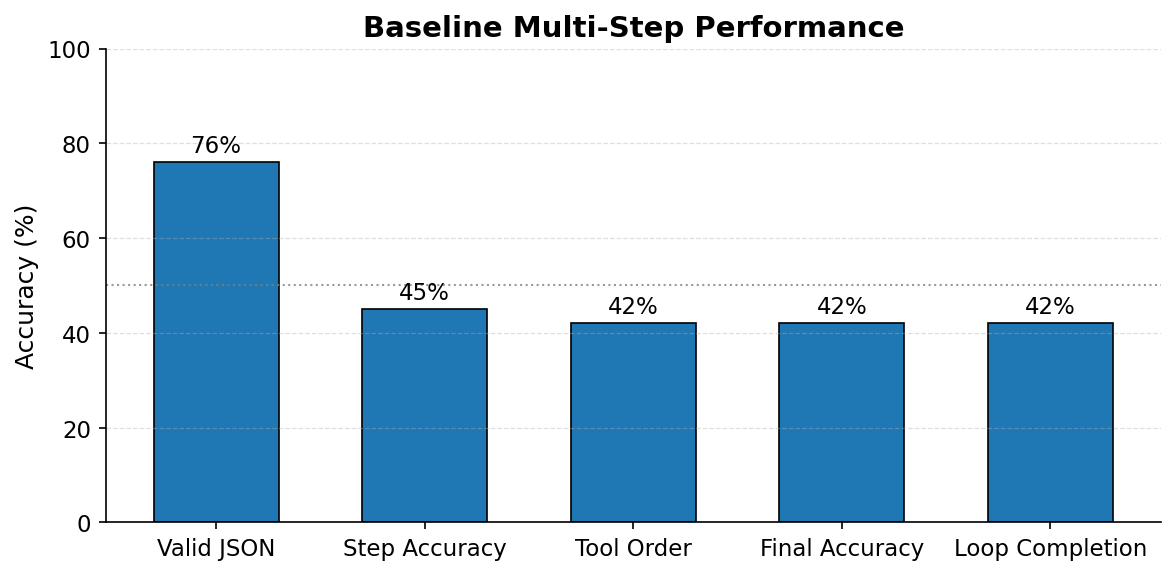

In [8]:
plot = pd.DataFrame(
    {
        "Metric": [
            "Valid JSON",
            "Step Accuracy",
            "Tool Order",
            "Final Accuracy",
            "Loop Completion",
        ],
        "Accuracy": [
            76,
            45,
            42,
            42,
            42,
        ],
    }
)

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(
    plot["Metric"],
    plot["Accuracy"],
    width=0.6,
    edgecolor="black",
    linewidth=0.8,
)

for bar in bars:
    value = bar.get_height()

    ax.annotate(
        f"{value:.0f}%",
        (
            bar.get_x() + bar.get_width() / 2,
            value
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        fontsize=11,
    )

ax.axhline(
    50,
    linestyle=":",
    linewidth=1,
    color="gray",
    alpha=0.8,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

ax.set_ylabel("Accuracy (%)")
ax.set_title("Baseline Multi-Step Performance")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

### Discussion

Unlike the single-step benchmark, the multi-step evaluation measures the complete routing pipeline. This includes lightweight orchestration components such as tool-name normalization, invalid tool filtering, and iterative execution. Therefore, the reported 42% accuracy should be interpreted as the performance of the baseline system rather than the raw Qwen2.5-3B-Instruct model.

Despite failing almost every single-step routing task, the model performs noticeably better during multi-step interactions.

This behaviour suggests that iterative reasoning partially compensates for the absence of an explicit routing policy.

However, overall performance remains far below the level required for a production assistant.

### Resource Usage

The base model requires approximately **2.8–3.0 GB** of resident memory during single-step inference and around **3.1 GB** during multi-step reasoning (measured average: 3,132 MB, see Notebook 02, Section “Experimental Setup”).

These measurements establish the hardware requirements used throughout the remainder of the project.

Figure 4 - Performance Comparison Across Evaluation Settings

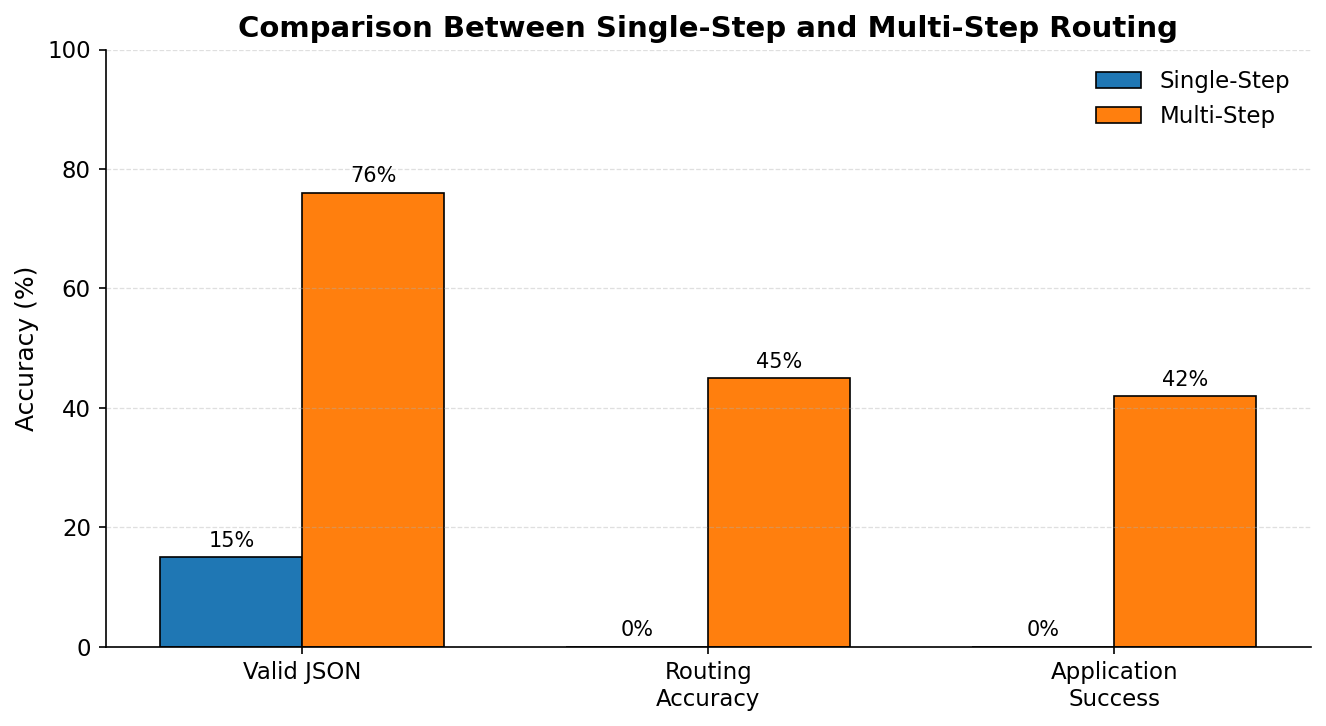

In [9]:
comparison = pd.DataFrame({
    "Metric": [
        "Valid JSON",
        "Routing\nAccuracy",
        "Application\nSuccess"
    ],
    "Single-Step": [
        15,
        0,
        0
    ],
    "Multi-Step": [
        76,
        45,
        42
    ]
})

x = np.arange(len(comparison))
width = 0.35

fig, ax = plt.subplots(figsize=(9,5))

bars1 = ax.bar(
    x - width/2,
    comparison["Single-Step"],
    width,
    label="Single-Step",
    edgecolor="black",
    linewidth=0.8,
)

bars2 = ax.bar(
    x + width/2,
    comparison["Multi-Step"],
    width,
    label="Multi-Step",
    edgecolor="black",
    linewidth=0.8,
)

for bars in (bars1, bars2):
    for bar in bars:
        height = bar.get_height()

        ax.annotate(
            f"{height:.0f}%",
            (
                bar.get_x() + bar.get_width()/2,
                height
            ),
            xytext=(0,5),
            textcoords="offset points",
            ha="center",
            fontsize=10
        )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4
)

ax.set_xticks(x)
ax.set_xticklabels(comparison["Metric"])

ax.set_ylim(0,100)

ax.set_ylabel("Accuracy (%)")

ax.set_title(
    "Comparison Between Single-Step and Multi-Step Routing"
)

ax.legend(frameon=False)

plt.tight_layout()

plt.show()

## Key Findings

The baseline evaluation highlights four important observations:

- The base model fails to perform reliable tool routing without task-specific guidance.
- Valid JSON generation remains limited, with only 15% of responses matching the expected schema.
- Parameter extraction occasionally succeeds despite incorrect tool selection, suggesting partial semantic understanding.
- Multi-step reasoning significantly outperforms single-step routing, indicating that iterative reasoning partially compensates for the absence of an explicit routing policy.

These observations motivate the prompt engineering phase presented in the next notebook.

## Conclusion

The baseline evaluation clearly demonstrates that the raw Qwen2.5-3B-Instruct model cannot reliably operate as a routing engine for a local AI assistant.

While the model exhibits promising reasoning capabilities during multi-step interactions, it lacks the routing knowledge necessary to consistently select the correct tools.

These results establish a strong baseline against which all subsequent improvements will be measured.

The next notebook investigates whether prompt engineering alone can bridge this gap before introducing any supervised learning.